## Refinement based on pure reweighting
to see the advantages of on-the-fly refinement

In [1]:
import os, pickle, copy
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')

from simpleMD import SimpleMD, generate_chain 
# if not is_run, SimpleMD is only required to load pickles

from my_tools import compute_SAXS

In [3]:
from MDRefine import load_data, minimizer

### 1. prepare data 
from `SimpleMD` outputs (in `data` directory) to `MDRefine` (new directory `polymer`)

In [ ]:
is_run = False
cell = (100., 100., 100.)

In [ ]:
if is_run:
    positions = generate_chain(10, 1.)
    keys_prior = {
        'temperature' : 0.722,
        'tstep' : 0.001,
        'friction' : 1.0,
        'forcecutoff' : 2.5,
        'k_fene' : 30.0,
        'maxbond' : 1.5,
        'q_SAXS' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'listcutoff' : 3.0,
        'nstep' : int(1e5),
        'nconfig' : 100,
        'nstat' : 100,
        'nequilib' : 10000,
        # pass the crystal lattice generated above
        'cell' : cell,
        'positions' : positions
        }
    
    print('run MD simulation with prior knowledge')
    smd_prior = SimpleMD(**keys_prior)
    smd_prior.run()

    print('run MD simulation for ground truth (to get experimental values)')
    keys_ref = copy.deepcopy(keys_prior)
    keys_ref.update({'k_angle' : 5.0})

    smd_reference = SimpleMD(**keys_ref)
    smd_reference.run()



In [ ]:
if not is_run:
    with open("../data/prior.pkl", "rb") as file:
        smd_prior = pickle.load(file)
    with open("../data/test.pkl", "rb") as file:
        smd_reference = pickle.load(file)

In [7]:
vars(smd_prior).keys()

dict_keys(['iv', 'iy', 'iset', 'gset', 'write_positions_first', 'write_statistics_first', 'write_statistics_last_time_reopened', 'write_statistics_fp', 'temperature', 'maxneighbors', 'tstep', 'friction', 'forcecutoff', 'k_fene', 'maxbond', 'k_angle', 'l_rgyr2', 'exp_rgyr2', 'k_rgyr2', 'tau_rgyr2', 'alpha_rgyr2', 'sigma_rgyr2', 'q_SAXS', 'l_SAXS', 'a_SAXS', 'b_SAXS', 'c_SAXS', 'exp_SAXS', 'k_SAXS', 'tau_SAXS', 'alpha_SAXS', 'sigma_SAXS', 'k_fm', 'tau_fm', 'listcutoff', 'nstep', 'nconfig', 'nstat', 'nequilib', 'nonthefly', 'idum', 'wrapatoms', 'statfile', 'trajfile', 'outputfile', 'inputfile', 'positions', 'cell', 'statfile_f', 'statistics', 'lambda_otf', 'SAXS_otf', 'fm_otf', 'trajectory', 'SAXS', 'grad_lambda', 'angle', 'output'])

#### `forward_qs`
from `smd_prior`

quantities required to compute the observables by evaluation of the `forward_model_fun` function
- in this case, SAXS values for each frame of the trajectory, since the correction to the forward model is a linear combination of them (for each frame)

In [8]:
traj = np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))])

print('shape of traj: ', traj.shape)

shape of traj:  (10100, 10, 3)


In [9]:
smd_prior.angle[5].shape

(101000,)

they have different number of frames (angle is saved every `nstat` iterations, while the trajectory every `nconfig`)

In [10]:
saxs = []

for i in range(len(traj)):
    saxs.append(compute_SAXS(traj[i], cell, smd_prior.q_SAXS))

saxs = np.array(saxs)

In [11]:
saxs.shape

(10100, 10)

In [12]:
!mkdir ../data_MDRefine
!mkdir ../data_MDRefine/polymer
!mkdir ../data_MDRefine/polymer/forward_qs

# if not 'saxs.npy' in os.listdir('../data_MDRefine/polymer/forward_qs'):
np.save('../data_MDRefine/polymer/forward_qs/saxs.npy', saxs)

mkdir: impossibile creare la directory "../data_MDRefine": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer/forward_qs": File già esistente


In [13]:
lines = ["A,1", "B,0"]

with open("../data_MDRefine/original_fm_coeffs", "w") as f:
    for line in lines:
        f.write(line + "\n")

#### experimental values
from `smd_reference`

from a logical point of view, `exp_saxs` should be exactly given by `smd_reference.SAXS` I would say, without linear combination that should be added to the prior...

In [14]:
exp_saxs = 1.5*smd_reference.SAXS + 2.0
sigma_saxs = 1.0*np.ones(len(exp_saxs))

exp_vals = np.vstack((exp_saxs, sigma_saxs)).T

!mkdir ../data_MDRefine/polymer/g_exp
np.save('../data_MDRefine/polymer/g_exp/saxs.npy', exp_vals)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/g_exp": File già esistente


In [15]:
!mkdir ../data_MDRefine/polymer/names
np.save('../data_MDRefine/polymer/names/saxs.npy', np.array(smd_reference.q_SAXS).T)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/names": File già esistente


In [16]:
assert (smd_reference.q_SAXS == smd_prior.q_SAXS), 'error: mismatch on q_SAXS'

### 2. load data

In [8]:
infos = {'global': {
    'path_directory': '../data_MDRefine',
    'system_names': ['polymer'],
    'g_exp': ['saxs'],
    'forward_qs': ['saxs'],
    'forward_coeffs': 'original_fm_coeffs'  # np.array([1., 0.])
}}

In [9]:
def forward_model_fun(fm_coeffs, forward_qs):
    forward_qs_out = {'saxs': fm_coeffs[0]*forward_qs['saxs'] + fm_coeffs[1]}
    return forward_qs_out

infos['global']['forward_model'] = forward_model_fun

In [10]:
data = load_data(infos)

loading data from directory...
loading  polymer
done


In [11]:
data.mol['polymer'].forward_qs['saxs'].shape

(10100, 10)

In [12]:
vars(data.mol['polymer']).keys()

dict_keys(['temperature', 'gexp', 'names', 'ref', 'forward_model', 'forward_qs', 'weights', 'g', 'n_experiments', 'n_frames'])

In [13]:
data.mol['polymer'].weights.shape

(10100,)

try with different regularizations for the coefficients of the forward model

In [62]:
def forward_model_regularization(coeffs, coeffs0):
    # L2 regularization
    regularization = (coeffs[0] - coeffs0[0])**2 + (coeffs[1] - coeffs0[1])**2
    
    # regularization used in the thesis
    # regularization = jnp.log(coeffs[0])
    return regularization

regularization = {'forward_model_reg' : forward_model_regularization}

### 2. minimize the loss function
purely based on reweighting initial trajectory

In [63]:
result = minimizer(data, regularization=regularization, alpha=1, gamma=1, if_print_biblio=False)

In [64]:
vars(result)

{'loss': Array(5.87099824, dtype=float64),
 'pars': array([ 1.55008549, -0.1477856 ]),
 'mini':   message: Desired error not necessarily achieved due to precision loss.
   success: False
    status: 2
       fun: 5.870998238563317
         x: [ 1.550e+00 -1.478e-01]
       nit: 8
       jac: [-5.397e-03 -1.330e-04]
  hess_inv: [[ 2.254e-03 -2.735e-02]
             [-2.735e-02  4.998e-01]]
      nfev: 27
      njev: 15,
 'min_lambdas': {'polymer': {'saxs': Array([ 0.06830218, -0.02442573, -0.11991673, -0.16382386, -0.12578257,
          -0.01773905,  0.11468109,  0.20972356,  0.22013807,  0.13428127],      dtype=float64)}},
 'minis': {'polymer':   message: Optimization terminated successfully.
    success: True
     status: 0
        fun: -5.546563607696522
          x: [ 3.930e-03 -5.462e-03 -5.758e-02 -1.312e-01 -1.455e-01
              -2.694e-02  2.133e-01  4.531e-01  5.287e-01  3.454e-01]
        nit: 0
        jac: [-5.098e-04 -8.033e-04  4.002e-04  3.724e-04  5.319e-04
          

In [65]:
new_weights = result.weights_new['polymer']

print(len(new_weights), len(smd_prior.angle[5]))

10100 101000


In [66]:
np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))]).shape

(10100, 10, 3)

5.453978922043949


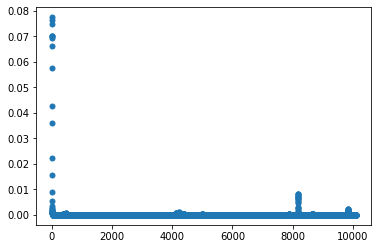

In [67]:
plt.plot(new_weights, '.')

p0 = 1/len(new_weights)
dkl = np.sum(new_weights*np.log(new_weights/p0))

print(dkl)

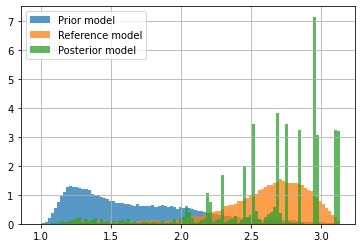

In [68]:
my_hist = {}

out = plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior model')
my_hist['prior'] = out[0]
bins = out[1]  # only in this way you can compare distributions by computing the D_KL

my_hist['reference'] = plt.hist(smd_reference.angle[3], bins=bins, density=True, alpha=0.75, label='Reference model')[0]
my_hist['reweighted'] = plt.hist(smd_prior.angle[3][::10], weights=new_weights, bins=bins, density=True, alpha=0.75, label='Posterior model')[0]

for k in my_hist.values():
    k /= np.sum(k)

# plt.yscale('symlog')
plt.grid()
plt.legend()

In [25]:
from my_tools import compute_dkl

In [57]:
dkl1 = compute_dkl(my_hist['reweighted'], my_hist['prior'])

dkl2 = compute_dkl(my_hist['reference'], my_hist['prior'])

print(dkl1, dkl2)

2.8671801569442263 1.6732657596940317


In [58]:
print('new coefficients of the forward model: ', result.pars)

new coefficients of the forward model:  [ 1.55033133 -0.15264052]


In [59]:
out_saxs = forward_model_fun(result.pars, data.mol['polymer'].forward_qs)['saxs']
out_saxs_av = np.mean(out_saxs, axis=0)
out_saxs_av2 = np.average(out_saxs, axis=0, weights=new_weights)


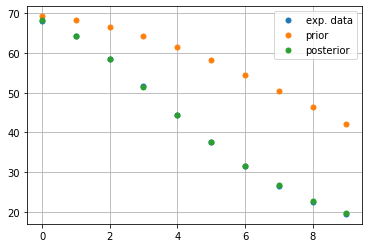

In [60]:
plt.rcParams['lines.markersize'] = 10

plt.plot(data.mol['polymer'].gexp['saxs'][:, 0], '.', label='exp. data')
plt.plot(out_saxs_av, '.', label='prior')
plt.plot(out_saxs_av2, '.', label='posterior')
plt.legend()
plt.grid()

### shuffle?
what happens?

In [32]:
arr = np.arange(len(data.mol['polymer'].weights))

np.random.shuffle(arr)

arr

array([7345, 8858, 8810, ..., 2515, 3965, 6916])

In [ ]:
data.mol['polymer'].forward_qs['saxs'] = data.mol['polymer'].forward_qs['saxs'][arr]
data.mol['polymer'].g['saxs'] = data.mol['polymer'].g['saxs'][arr]
data.mol['polymer'].weights = data.mol['polymer'].weights[arr]

I get the same result by `minimizer`, as it must be
(I was quite surprised by the plot of the new weights, since it seemed that only initial weights were modified)